In [1]:
import numpy as np, matplotlib.pyplot as plt, seaborn as sns, pandas as pd
from pathlib import Path

Path("../data").mkdir(parents=True, exist_ok=True)
df = sns.load_dataset('titanic')
df.to_csv('../data/titanic.csv', index=False)

mu = 170
sigma = 5
count = 100000

s = np.random.normal(mu, sigma, count)
s_mean = np.mean(s)
cnt = 0

down_g = []
up_g = []
g = []

Я создал массив чисел и посчитал среднее для него

Теперь я создам 100 выборок из 30 и посчиатаю для них доверительные интервалы и посмотрю в скольки из них войдет истинное значение, предпологаю что около 95

In [2]:
for _ in range(100):
    choice = np.random.choice(s, size=30, replace=True)
    p = np.mean(choice)
    SE = np.std(choice, ddof=1) / 30**0.5
    down_g.append(p - 1.96 * SE)
    up_g.append(p + 1.96 * SE)
    if p - 1.96 * SE <= s_mean <= p + 1.96 * SE:
        g.append(True)
        cnt += 1
    else:
        g.append(False)

print(cnt / 100)

0.95


Как я и предпологал 91 случай из 100

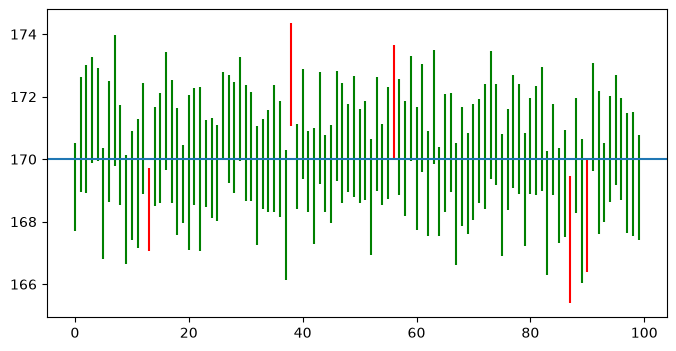

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
for i in range(100):
    if g[i]:
        ax.vlines(x=i, ymin=down_g[i], ymax=up_g[i], colors='green')
    else:
        ax.vlines(x=i, ymin=down_g[i], ymax=up_g[i], colors='red')
ax.axhline(y=s_mean)
plt.show()

In [4]:
len(down_g), len(up_g), len(g)

(100, 100, 100)

Для тех кто старше 64

In [5]:
ms = []
p = 1/11
n = 11
SE = (p * (1 - p) / n)**0.5
print(p - 2 * SE, p + 2 * SE)
weight = (p + 2 * SE) - (p - 2 * SE)
print(weight)
ms.append(p / weight)

-0.08244774349919859 0.2642659253173804
0.346713668816579


Из 11 людей 1 выживший и 10 погибших, доверительный интервал широкий, левая часть ушла за минус

Для 2 класс из Квинстауна

In [6]:
p = 2/3
n = 3
SE = (p * (1 - p) / n)**0.5
print(p - 2 * SE, p + 2 * SE)
weight = (p + 2 * SE) - (p - 2 * SE)
print(weight)
ms.append(p / weight)

0.12233561271484927 1.2109977206184839
1.0886621079036347


Из 3 людей выжило 2, доверительный интервал широкий, ширина больше 1

Для мужчин 3 класса

In [7]:
p = 47/347
n = 347
SE = (p * (1 - p) / n)**0.5
print(p - 2 * SE, p + 2 * SE)
weight = (p + 2 * SE) - (p - 2 * SE)
print(weight)
ms.append(p / weight)

0.09870616240305403 0.17218720935487103
0.073481046951817


Из 347 людей выжило 47, доверительный интервал не широкий

In [8]:
print(ms)

[0.2622022120425379, 0.6123724356957945, 1.843287371337777]


Отношения у 1 и 2 получились маленькие, меньше единицы, когда у 3 почти 2

По итогу только в 3 можно доверять результатам, когда в 1 и 2 интервалы слишком широкие

In [9]:
for n in [10, 30, 100, 400, 1600]:
    choice = np.random.choice(s, size=n, replace=True)
    p = np.mean(choice)
    SE = np.std(choice, ddof=1) / n**0.5
    print((p + 2 * SE) - (p - 2 * SE))

8.353328920656338
3.1299552801660298
2.2079881304531455
0.9399812474447344
0.4935339978683828


In [10]:
for sigma in [5, 15, 45]:
    q = np.random.normal(mu, sigma, count)
    choice = np.random.choice(q, size=30, replace=True)
    p = np.mean(choice)
    SE = np.std(choice, ddof=1) / 30**0.5
    print((p + 2 * SE) - (p - 2 * SE))

4.28325037592964
11.10142406837565
26.56759522898193


In [11]:
choice = np.random.choice(s, size=100, replace=True)
p = np.mean(choice)
SE = np.std(choice, ddof=1) / 100**0.5
for factor in [1.645, 1.96, 2.576]:
    print((p + factor * SE) - (p - factor * SE))

1.5838653696084748
1.8871587382569146
2.480265770280539


для 1 класса

In [12]:
class1_data = df[df['pclass'] == 1]
class1_p = class1_data['survived'].mean()
class1_n = class1_data.shape[0]
class1_SE = (class1_p * (1 - class1_p) / class1_n)**0.5
class1_down = class1_p - 1.96 * class1_SE
class1_up = class1_p + 1.96 * class1_SE

для 2 класса

In [13]:
class2_data = df[df['pclass'] == 2]
class2_p = class2_data['survived'].mean()
class2_n = class2_data.shape[0]
class2_SE = (class2_p * (1 - class2_p) / class2_n)**0.5
class2_down = class2_p - 1.96 * class2_SE
class2_up = class2_p + 1.96 * class2_SE

для 3 класса

In [14]:
class3_data = df[df['pclass'] == 3]
class3_p = class3_data['survived'].mean()
class3_n = class3_data.shape[0]
class3_SE = (class3_p * (1 - class3_p) / class3_n)**0.5
class3_down = class3_p - 1.96 * class3_SE
class3_up = class3_p + 1.96 * class3_SE

Для женщин

In [15]:
w_data = df[df['sex'] == 'female']
w_p = w_data['survived'].mean()
w_n = w_data.shape[0]
w_SE = (w_p * (1 - w_p) / w_n)**0.5
w_down = w_p - 1.96 * w_SE
w_up = w_p + 1.96 * w_SE

для мужчиин

In [16]:
m_data = df[df['sex'] == 'male']
m_p = m_data['survived'].mean()
m_n = m_data.shape[0]
m_SE = (m_p * (1 - m_p) / m_n)**0.5
m_down = m_p - 1.96 * m_SE
m_up = m_p + 1.96 * m_SE

In [17]:
my_data = pd.DataFrame({
    'class 1': [class1_p, class1_SE, class1_down, class1_up, class1_n],
    'class 2': [class2_p, class2_SE, class2_down, class2_up, class2_n],
    'class 3': [class3_p, class3_SE, class3_down, class3_up, class3_n],
    'women': [w_p, w_SE, w_down, w_up, w_n],
    'men': [m_p, m_SE, m_down, m_up, m_n],
    },
   index=['mean', 'SE', 'bottom', 'top', 'count']
)
my_data

,class 1,class 2,class 3,women,men
mean,0.629630,0.472826,0.242363,0.742038,0.188908
SE,0.032857,0.036806,0.019338,0.024690,0.016296
bottom,0.565229,0.400686,0.204459,0.693645,0.156969
top,0.694030,0.544966,0.280266,0.790431,0.220848
count,216.000000,184.000000,491.000000,314.000000,577.000000


По таблице видно что интервалы 1 и 3 класса не пересекаются и находятся далеко друг от друга что говорит о колосальном различии в шансах на выживание, то же самое насчёт женщин и мужчин

<Axes: xlabel='pclass', ylabel='survived'>

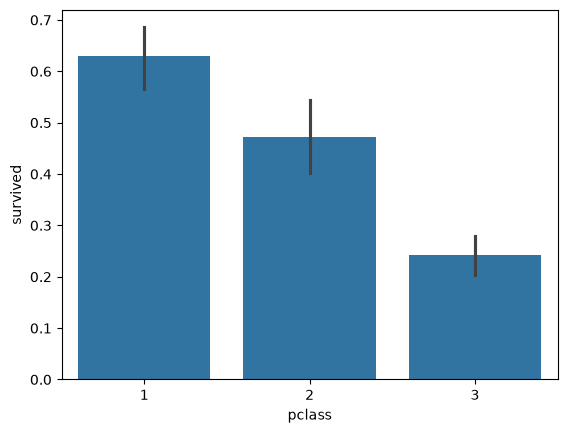

In [18]:
sns.barplot(data=df, x='pclass', y='survived', errorbar=('ci', 95))

- [x] пересечение интервалов: пары 1-2, 2-3, 1-3
- [x] то же для женщин и мужчин
- [x] сформулировать правило
- [x] таблица по портам, найти пересекающуюся пару
- [x] сравнить усы barplot с таблицей численно

Никакие интервалы не пересеклись, для выживаемости это значит, что на выживаемость влиял то, какой у тебя класс, у мужчин и женщин так же нет пересечений, это значит что пол влиял на выживаемость

При коэфиценте 1.96 показывает в каком промежутке может быть истинное среднее с вероятностью 95% и если у одной характеристики интервалы не пересекаются это значит, что результат вряд ли объясняется случайностью выборки

<Axes: xlabel='embarked', ylabel='survived'>

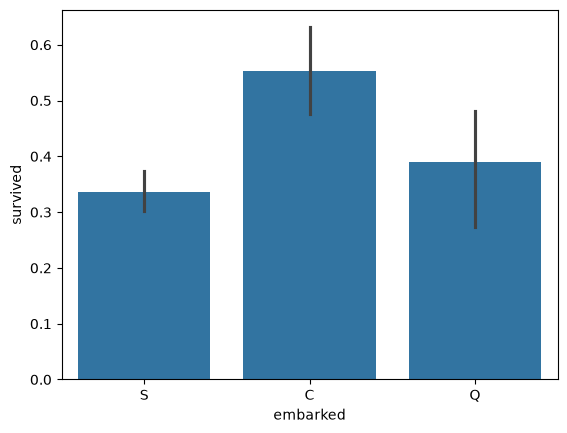

In [19]:
sns.barplot(data=df, x='embarked', y='survived', errorbar=('ci', 95))

Интервалы столбца C и Q пересекаются

[0.56481481 0.69444444]
[0.39673913 0.54361413]
[0.20768839 0.28105906]


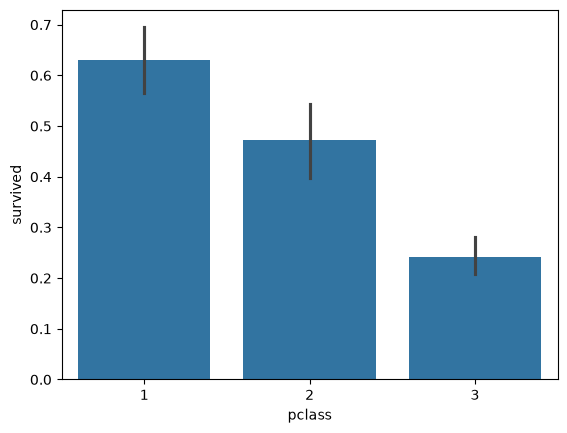

In [20]:
fig, ax = plt.subplots()
sns.barplot(data=df, x='pclass', y='survived', errorbar=('ci', 95), ax=ax)
for line in ax.lines:
    print(line.get_ydata())

Сравниваю 1 класс
по таблице: 0.56 - 0.69 По графику: 0.56 - 0.69 -> Совпадение (но если смотреть дальше чем до 2 чисел после целой части, то дам уже будут маленькие различия)

Сравниваю 2 класс
по таблице: 0.40 - 0.54 По графику: 0.40 - 0.54 -> Совпадение (но если смотреть дальше чем до 2 чисел после целой части, то дам уже будут маленькие различия)

Сравниваю 3 класс
по таблице: 0.20 - 0.27 По графику: 0.20 - 0.27 -> Совпадение (но если смотреть дальше чем до 3 чисел после целой части, то дам уже будут маленькие различия)